# TP3 Fonctions descriptives 

Membres de l'équipe : 
- Titouan CHOALER chot4078
- Ethan BROUILLET broe5997

## 1. Segmentation des données suivant la longueur des séquences

### (a). Visualisation de la distribution des longueurs des séquences dans l’ensemble des données à l’aide d’un histogramme

On charge les données, calcule la longueur de chaque séquence d'ARN et génère l'histogramme requis :

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('TP3-data.csv')
df['longueur'] = df['sequence'].apply(len)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        900 non-null    object
 1   sequence  900 non-null    object
 2   longueur  900 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 21.2+ KB


,id,sequence,longueur
0,AAIY01303410.1/717-923,CCAACGUGGAUACUCCCGGGAGGUCACUCUCCCCGGGCUCUGUCCA...,207
1,CP000140.1/4143906-4143709,UACCUUUGCAUCCGAAUUGGUUCCGUACGCUCGUUCGGGCAUACGG...,198
2,URS0000D6BCE7_12908/1-215,GCGUAACGCGCUAUGGCUUAAACGGCUGCCCCAAAGCUGCCAAAGG...,215
3,X71081.1/4425-4646,CCAAUGUGGAUAUCCUUAGAGGUCUCUCUUGGGCUCUGUCCAGGUG...,222
4,AACY020770731.1/455-512,UUUCGUUCACCCUCAAUUGAGGGCGCAGUUCGAGUCAUACCAUGGA...,58


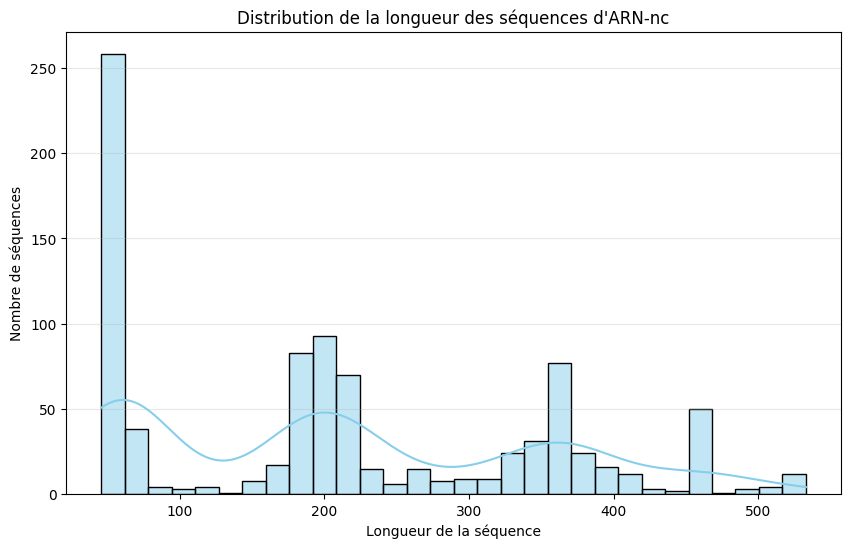

In [2]:
plt.figure(figsize=(10, 6))
sns.histplot(df['longueur'], bins=30, kde=True, color='skyblue')
plt.title('Distribution de la longueur des séquences d\'ARN-nc')
plt.xlabel('Longueur de la séquence')
plt.ylabel('Nombre de séquences')
plt.grid(axis='y', alpha=0.3)
plt.show()

### (b) Proposition et justification d'un premier partitionnement des données en groupes de séquences de longueurs similaires

Pour nous aider, on affiche les statistiques lié à la longueur de la séquence.

In [3]:
print(df['longueur'].describe())

count    900.000000
mean     212.873333
std      137.177984
min       46.000000
25%       62.000000
50%      198.000000
75%      345.250000
max      533.000000
Name: longueur, dtype: float64


L'observation de l'histogramme de la distribution des longueurs révèle une répartition multimodale des 900 séquences d'ARN-nc, caractérisée par trois pics principaux de densité. Le premier regroupement se situe autour d'une longueur de 60 nucléotides, englobant le premier quartile. Un deuxième ensemble, plus intermédiaire, se concentre autour de la médiane à 200 nucléotides. Et enfin, un troisième groupe s'étire vers les séquences plus longues, avec un centre de gravité autour de 360 nucléotides. Bien qu'un quatrième pic apparaisse au-delà de 450 nucléotides, isoler ce quatrième groupe générerait une classe fortement sous-représentée. Pour maintenir des échantillons de taille suffisante et ainsi garantir la pertinence des algorithmes de partitionnement, on a choisi de faire que trois groupes.

Les seuils de coupure ont été placés stratégiquement dans les creux de la distribution, soit à 130 et 280 nucléotides, là où la densité de séquences est minimale. Ce choix permet de réduire au maximum le risque de scinder arbitrairement une même famille biologique d'ARN en deux groupes distincts.  La segmentation finale retenue s'articule donc ainsi :  
- un groupe de séquences courtes (longueur inférieure ou égale à 130),  
- un groupe de séquences moyennes (strictement supérieure à 130 et inférieure ou égale à 280),  
- un groupe de séquences longues (strictement supérieure à 280).

#### Implémentation de la segmentation :

In [4]:
seuils = [130, 280]

g_court = df[df['longueur'] < seuils[0]].copy()
g_moyen = df[(df['longueur'] >= seuils[0]) & (df['longueur'] < seuils[1])].copy()
g_long = df[(df['longueur'] >= seuils[1])].copy()

groupes = [g_court, g_moyen, g_long]
for i, g in enumerate(groupes, 1):
    print(f"Groupe {i} : {len(g)} séquences (Min: {g['longueur'].min()}, Max: {g['longueur'].max()})")

Groupe 1 : 307 séquences (Min: 46, Max: 127)
Groupe 2 : 311 séquences (Min: 136, Max: 277)
Groupe 3 : 282 séquences (Min: 280, Max: 533)


## 2. Partitionnement à partir d’une représentation vectorielle des données

### (a). Génération d'une représentation vectorielle des séquences (2-mer, 3-mer et 4-mer)

Pour projeter les propriétés structurelles des ARN dans un espace exploitable par l'algorithme des K-moyennes, on décompose les séquences en motifs de taille fixe (k-mers) :  
* 2-mers : AA, AC, AG, AU, CA, etc. ($4^2 = 16$ combinaisons).
* 3-mers : AAA, AAC, etc. ($4^3 = 64$ combinaisons).
* 4-mers : AAAA, AAAC, etc. ($4^4 = 256$ combinaisons).   

Total des attributs par vecteur : $16 + 64 + 256 = 336$.   

L'extraction de l'ensemble des 2-mers, 3-mers et 4-mers possibles à partir de l'alphabet nucléotidique {A, C, G, U} génère donc un espace vectoriel initial de 336 dimensions. Il est indispensable lors de cette transformation de convertir les comptes d'occurrences bruts de ces motifs en fréquences relatives (normalisation L1). Les longueurs de séquences fluctuant naturellement au sein d'un même groupe, conserver des valeurs absolues contraindrait l'algorithme à regrouper les objets sur la base de leur longueur résiduelle plutôt que sur la similarité de leurs profils sémantiques et biologiques.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import normalize
import itertools

def extraire_kmers(df_groupe):
    """
    Génère une représentation vectorielle basée sur les 2-mer, 3-mer et 4-mer.
    """
    alphabet = ['A', 'C', 'G', 'U']
    
    # Génération de la liste complète de tous les k-mers possibles (le vocabulaire)
    vocabulaire_complet = []
    for k in [2, 3, 4]:
        combinaisons = [''.join(p) for p in itertools.product(alphabet, repeat=k)]
        vocabulaire_complet.extend(combinaisons)
    
    vectorizer = CountVectorizer(analyzer='char', 
                                 ngram_range=(2, 4),
                                 lowercase=False, # Ne pas convertir en minuscules  
                                 vocabulary=vocabulaire_complet)
    
    X_counts = vectorizer.fit_transform(df_groupe['sequence'])
    X_freqs = normalize(X_counts, norm='l1', axis=1)
    
    df_vectorise = pd.DataFrame(X_freqs.toarray(), 
                                columns=vectorizer.get_feature_names_out(), 
                                index=df_groupe.index)
    
    return df_vectorise

X_court = extraire_kmers(g_court)
X_moyen = extraire_kmers(g_moyen)
X_long = extraire_kmers(g_long)

print(f"Dimensions de la matrice 'Court' : {X_court.shape}")

Dimensions de la matrice 'Court' : (307, 336)


Comme les algorithmes de partitionnement (K-means) ne peuvent pas traiter directement du texte, cette méthode de "sac de mots" (bag-of-words) adaptée à la biologie permet de projeter les propriétés structurelles des ARN dans un espace numérique.

### (b). Filtrage des motifs fréquents

Un motif (sous-chaîne) est considéré comme frequent si sa proportion de présence dans l'ensemble des séquences d'un groupe est supérieure ou égale à $1/3$.

Le retrait des motifs dont la proportion de présence est inférieure à 1/3 est essentiel pour garantir la performance et la pertinence du partitionnement.

In [6]:
def filtrer_motifs_frequents(df_vectorise):
    """
    Supprime les colonnes (motifs) dont la proportion de présence est < 1/3.
    """
    presence = (df_vectorise > 0).astype(int)
    proportion = presence.mean()
    motifs_a_garder = proportion[proportion >= 1/3].index

    return df_vectorise[motifs_a_garder]

X_court_filtre = filtrer_motifs_frequents(X_court)
X_moyen_filtre = filtrer_motifs_frequents(X_moyen)
X_long_filtre = filtrer_motifs_frequents(X_long)

print(f"Colonnes restantes (Court) : {X_court_filtre.shape[1]}")
print(f"Colonnes restantes (Moyen) : {X_moyen_filtre.shape[1]}")
print(f"Colonnes restantes (Long)  : {X_long_filtre.shape[1]}")

Colonnes restantes (Court) : 108
Colonnes restantes (Moyen) : 322
Colonnes restantes (Long)  : 335


Pourquoi est-il important de retirer les motifs les moins fréquents ?    

Premièrement, cette étape permet de lutter contre le "fléau de la dimension" (curseurs of dimensionality). En passant d'un espace de 336 k-mers à un sous-ensemble de motifs fréquents, on réduit la complexité de l'espace vectoriel. Dans un espace à trop haute dimension, la distance euclidienne utilisée par l'algorithme des K-moyennes perd de son efficacité car toutes les données semblent être à une distance similaire les unes des autres. En se concentrant sur les attributs les plus représentatifs, on aide l'algorithme à mieux distinguer les groupes.

Deuxièmement, l'élimination des motifs rares permet de supprimer le bruit statistique. Les k-mers présents dans très peu de séquences sont souvent le résultat de variations isolées, de mutations spécifiques ou d'erreurs de séquençage qui n'ont aucune signification biologique globale. Conserver ces motifs forcerait l'algorithme à prendre en compte des détails non pertinents, ce qui pourrait conduire à un sur-apprentissage (overfitting) et fragmenter les clusters de manière artificielle.

Enfin, l'objectif du TP est de regrouper les ARN par familles fonctionnelles. Les fonctions biologiques sont généralement portées par des motifs conservés au sein d'un même groupe. En ne gardant que les motifs fréquents, on s'assure que le partitionnement repose sur des caractéristiques partagées par une part significative de la population, maximisant ainsi les chances que les clusters formés correspondent à de véritables catégories biologiques cohérentes.

### (c). Recherche du nombre optimal de clusters ($k$) par K-moyennes

Pour identifier le nombre optimal de familles d'ARN (k) au sein de chaque groupe de longueurs, on évalue des configurations itérativement avec l'algorithme des K-moyennes et le calcul du coefficient de Silhouette. 
Le coefficient de Silhouette varie entre -1 et 1 : 
* Proche de 1 : Les données sont très bien classées dans leur cluster et loin des autres.
* Proche de 0 : Les clusters se chevauchent.
* Négatif : Des données ont probablement été assignées au mauvais cluster.  

Cet indicateur quantifie simultanément la cohésion interne des clusters formés et la netteté de la séparation entre ces clusters, fournissant ainsi un critère objectif pour trancher. 

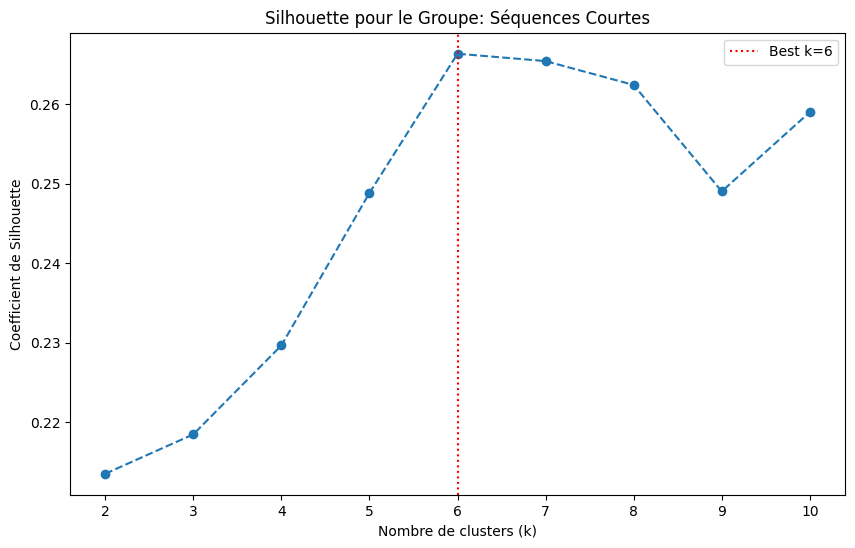

Pour le groupe Séquences Courtes, la meilleure valeur est k = 6 (Score: 0.2664)


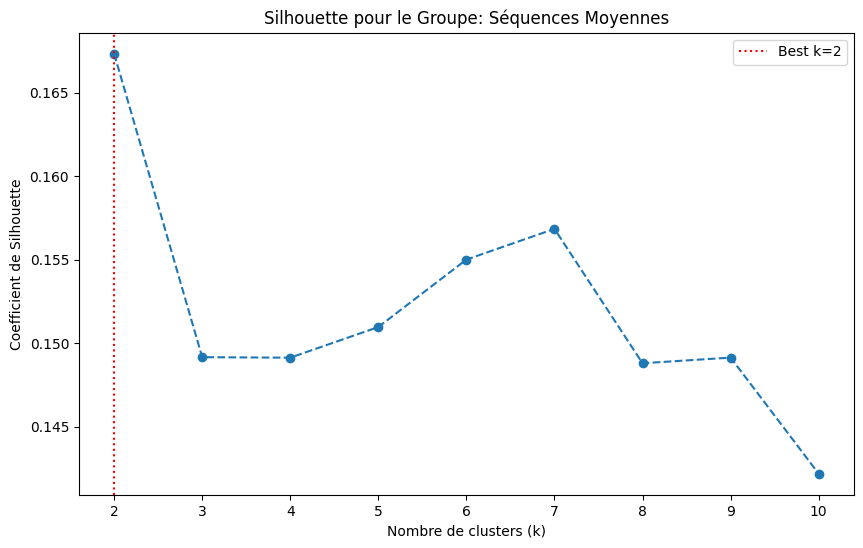

Pour le groupe Séquences Moyennes, la meilleure valeur est k = 2 (Score: 0.1673)


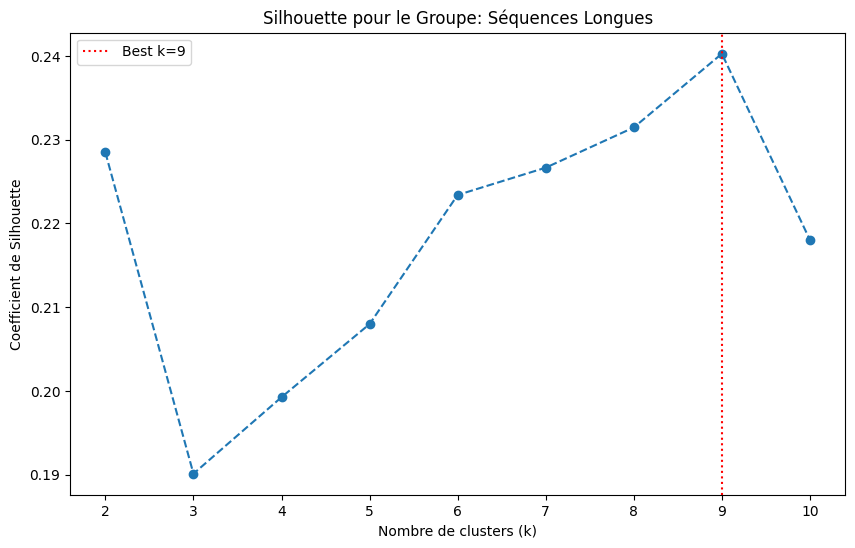

Pour le groupe Séquences Longues, la meilleure valeur est k = 9 (Score: 0.2403)


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def trouver_meilleur_k(X_filtre, nom_groupe):
    """
    Teste plusieurs valeurs de k pour un groupe donné et retourne le meilleur k
    selon le score de Silhouette.
    """
    scores = []
    meilleur_k = 2
    meilleur_score = -1
    plage_k = range(2, 11)
    
    for k in plage_k:
        model = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = model.fit_predict(X_filtre)
        score = silhouette_score(X_filtre, labels)
        scores.append(score)
        
        if score > meilleur_score:
            meilleur_score = score
            meilleur_k = k
            
    plt.figure(figsize=(10, 6))
    plt.plot(plage_k, scores, marker='o', linestyle='--')
    plt.title(f'Silhouette pour le Groupe: {nom_groupe}')
    plt.xlabel('Nombre de clusters (k)')
    plt.ylabel('Coefficient de Silhouette')
    plt.axvline(x=meilleur_k, color='r', linestyle=':', label=f'Best k={meilleur_k}')
    plt.legend()
    plt.show()
    
    print(f"Pour le groupe {nom_groupe}, la meilleure valeur est k = {meilleur_k} (Score: {meilleur_score:.4f})")
    return meilleur_k

k_court = trouver_meilleur_k(X_court_filtre, "Séquences Courtes")
k_moyen = trouver_meilleur_k(X_moyen_filtre, "Séquences Moyennes")
k_long  = trouver_meilleur_k(X_long_filtre,  "Séquences Longues")

Les résultats désignent k=6 comme le partitionnement le plus pertinent pour les séquences courtes (score de 0.2664), k=2 pour les séquences moyennes (score de 0.1673), et k=9 pour les séquences longues (score de 0.2403). Ces résultats montrent que les séquences biologiques sont complexe et donc pas facilement dissociables.

## 3. Partitionnement à partir d'une matrice de distances

### (a). Génération de la matrice des distances d'édition

La construction de la matrice de distances repose sur le calcul d'un score d'alignement global entre chaque paire de séquences d'ARN (grâce au module pairwise2). Le traitement d'un tel calcul présente une complexité quadratique. Pour pallier partiellement la lenteur d'exécution de pairwise2, on a limité le calcul à la partie triangulaire supérieure de la matrice (la matrice de distance étant symétrique).

In [10]:
from Bio import pairwise2
import numpy as np

def calculer_matrice_distances(df_groupe):
    """
    Calcule la matrice carrée des distances d'édition simple entre les séquences.
    """
    n = len(df_groupe)
    sequences = df_groupe['sequence'].tolist()
    matrice_dist = np.zeros((n, n))
    
    print(f"Calcul de la matrice pour {n} séquences...")
    
    for i in range(n):
        for j in range(i + 1, n):
            alignments = pairwise2.align.globalxx(sequences[i], sequences[j])
            
            # Formule fournie par le sujet : distance = min(longueur - score)
            dist = min([aln[4] - aln[2] for aln in alignments])
            
            matrice_dist[i, j] = dist
            matrice_dist[j, i] = dist
            
        if (i + 1) % 50 == 0:
            print(f"Progression : {i + 1}/{n} séquences traitées")
            
    return matrice_dist

dist_court = calculer_matrice_distances(g_court)
dist_moyen = calculer_matrice_distances(g_moyen)
dist_long  = calculer_matrice_distances(g_long)

Calcul de la matrice pour 307 séquences...
Progression : 50/307 séquences traitées
Progression : 100/307 séquences traitées
Progression : 150/307 séquences traitées
Progression : 200/307 séquences traitées
Progression : 250/307 séquences traitées
Progression : 300/307 séquences traitées
Calcul de la matrice pour 311 séquences...
Progression : 50/311 séquences traitées
Progression : 100/311 séquences traitées
Progression : 150/311 séquences traitées
Progression : 200/311 séquences traitées
Progression : 250/311 séquences traitées
Progression : 300/311 séquences traitées
Calcul de la matrice pour 282 séquences...
Progression : 50/282 séquences traitées
Progression : 100/282 séquences traitées
Progression : 150/282 séquences traitées
Progression : 200/282 séquences traitées
Progression : 250/282 séquences traitées


### (b). Implémentation de la fonction KMedoid

In [16]:
def KMedoid(n_clusters, X_dist, max_iter=100, n_init=10, random_state=42):
    """
    Implémentation de l'algorithme k-médoïdes. 
    """
    np.random.seed(random_state)
    n = X_dist.shape[0  ]
    meilleure_inertie = float('inf')
    meilleurs_labels = np.zeros(n, dtype=int)
    
    for _ in range(n_init):
        indices_medoides = np.random.choice(n, n_clusters, replace=False)
        y = np.zeros(n, dtype=int)
        
        for _ in range(max_iter):
            distances_aux_medoides = X_dist[:, indices_medoides]
            y_nouveau = np.argmin(distances_aux_medoides, axis=1)
            
            if np.array_equal(y, y_nouveau):
                break
            y = y_nouveau

            nouveaux_indices_medoides = np.zeros(n_clusters, dtype=int)
            for k in range(n_clusters):
                indices_cluster_k = np.where(y == k)[0]
                if len(indices_cluster_k) == 0:
                    distance_max_index = np.argmax(np.min(X_dist[:, indices_medoides], axis=1))
                    nouveaux_indices_medoides[k] = distance_max_index
                    continue
                sous_matrice_dist = X_dist[np.ix_(indices_cluster_k, indices_cluster_k)]
                somme_distances = sous_matrice_dist.sum(axis=1)
                index_local_medoide = np.argmin(somme_distances)
                nouveaux_indices_medoides[k] = indices_cluster_k[index_local_medoide]

            indices_medoides = nouveaux_indices_medoides
        
        inertie = 0
        for k in range(n_clusters):
            indices_cluster_k = np.where(y == k)[0]
            if len(indices_cluster_k) > 0:
                inertie += np.sum(X_dist[indices_cluster_k, indices_medoides[k]])
                
        if inertie < meilleure_inertie:
            meilleure_inertie = inertie
            meilleurs_labels = y.copy()
    return meilleurs_labels

### (c). Recherche de la meilleure valeur de $k$ pour les k-médoïdes

In [17]:
def trouver_meilleur_k_medoide(matrice_dist, nom_groupe):
    meilleur_k = 2
    meilleur_score = -1
    
    for k in range(2, 11):
        labels = KMedoid(k, matrice_dist)
        score = silhouette_score(matrice_dist, labels, metric="precomputed")
        
        if score > meilleur_score:
            meilleur_score = score
            meilleur_k = k
            
    print(f"Meilleur k pour {nom_groupe} : {meilleur_k} (Silhouette: {meilleur_score:.4f})")
    return meilleur_k

k_med_court = trouver_meilleur_k_medoide(dist_court, "Séquences Courtes")
k_med_moyen = trouver_meilleur_k_medoide(dist_moyen, "Séquences Moyennes")
k_med_long  = trouver_meilleur_k_medoide(dist_long,  "Séquences Longues")

Meilleur k pour Séquences Courtes : 6 (Silhouette: 0.4424)
Meilleur k pour Séquences Moyennes : 8 (Silhouette: 0.1960)
Meilleur k pour Séquences Longues : 8 (Silhouette: 0.3147)


Contrairement à l'algorithme des K-moyennes qui calcule un centroïde virtuel, le K-Médoïdes impose que le centre de chaque cluster soit une séquence existante dans le jeu de données. Cette contrainte est importante en biologie , car elle garantit que le représentant du cluster est une molécule biologiquement viable et non une construction mathématique abstraite. Noter algorithme a plusieurs initialisations aléatoires pour contourner les minimums locaux et la sélection du nombre optimal de clusters est déterminée par l'évaluation du coefficient de silhouette calculé directement sur la matrice des distances.

L'évaluation des différentes partitions générées par l'algorithme K-Médoïdes, nous donne :
- Séquences courtes : k=6 (Score de silhouette : 0.4424)
- Séquences moyennes : k=8 (Score de silhouette : 0.1960)
- Séquences longues : k=8 (Score de silhouette : 0.3147)

On observe que le partitionnement est plus performant sur les séquences courtes (comme pour les k-moyennes). Mais globalement on a des meilleurs résultats qu'avec les k-moyennes donc la métrique des médoïdes est meilleurs pour séparer les clusters.

## 4. Analyse de la signification sémantique

### (a). Analyse par représentation vectorielle (K-moyennes)

In [ ]:
model_court = KMeans(n_clusters=6, n_init=10, random_state=42).fit(X_court_filtre)
labels_court_km = model_court.labels_

model_moyen = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_moyen_filtre)
labels_moyen_km = model_moyen.labels_

model_long = KMeans(n_clusters=9, n_init=10, random_state=42).fit(X_long_filtre)
labels_long_km = model_long.labels_

def analyser_clusters_kmers(X_filtre, labels, nom_groupe):
    print(f"=== ANALYSE : {nom_groupe} (K-moyennes) ===")
    df_temp = X_filtre.copy()
    df_temp['cluster'] = labels
    moyenne_globale = X_filtre.mean()
    moyennes_clusters = df_temp.groupby('cluster').mean()
    
    communs = moyenne_globale.sort_values(ascending=False).head(5).index.tolist()
    print(f"Motifs communs au groupe : {communs}")
    
    for i in range(len(moyennes_clusters)):
        specif = (moyennes_clusters.loc[i] - moyenne_globale).sort_values(ascending=False).head(3).index.tolist()
        print(f"  > Cluster {i} - Signatures spécifiques : {specif}")
    print("")

analyser_clusters_kmers(X_court_filtre, labels_court_km, "Séquences Courtes")
analyser_clusters_kmers(X_moyen_filtre, labels_moyen_km, "Séquences Moyennes")
analyser_clusters_kmers(X_long_filtre, labels_long_km, "Séquences Longues")

=== ANALYSE : Séquences Courtes (K-moyennes) ===
Motifs communs au groupe : ['AA', 'GC', 'CA', 'AU', 'UG']
  > Cluster 0 - Signatures spécifiques : ['CC', 'CG', 'GG']
  > Cluster 1 - Signatures spécifiques : ['AA', 'AAA', 'UUG']
  > Cluster 2 - Signatures spécifiques : ['AA', 'UA', 'UAA']
  > Cluster 3 - Signatures spécifiques : ['UA', 'AU', 'CA']
  > Cluster 4 - Signatures spécifiques : ['AG', 'GU', 'GC']
  > Cluster 5 - Signatures spécifiques : ['GG', 'GGG', 'UC']

=== ANALYSE : Séquences Moyennes (K-moyennes) ===
Motifs communs au groupe : ['AA', 'UG', 'GG', 'AG', 'GA']
  > Cluster 0 - Signatures spécifiques : ['AA', 'UA', 'UU']
  > Cluster 1 - Signatures spécifiques : ['CC', 'CG', 'GG']

=== ANALYSE : Séquences Longues (K-moyennes) ===
Motifs communs au groupe : ['GG', 'AA', 'GC', 'AG', 'CC']
  > Cluster 0 - Signatures spécifiques : ['AA', 'UA', 'AU']
  > Cluster 1 - Signatures spécifiques : ['AA', 'AAA', 'UC']
  > Cluster 2 - Signatures spécifiques : ['CG', 'GG', 'GC']
  > Cluster

L'analyse des motifs k-mers met en évidence des différences claires dans la composition des groupes d'ARN, ce qui nous permet de déduire des propriétés physiques et fonctionnelles.

Pour les séquences courtes, on observe deux grandes tendances. On voit que les clusters 0 et 5 ont une forte présence de motifs "GC" (comme CC, CG, GG). En biologie, les liaisons entre G et C sont les plus fortes, ces clusters regroupent donc des ARN qui ont une structure très stable et rigide. À l'inverse, les clusters 1, 2 et 3 sont riches en adénine et uracile (AA, UA, UAA). Ces liaisons étant plus faibles, l'algorithme a isolé ici des ARN beaucoup plus flexibles, dont la structure ouverte leur permet sûrement d'interagir avec d'autres molécules.

Cette séparation physique est encore plus évidente pour les séquences moyennes. L'algorithme des K-moyennes a divisé ce groupe de manière binaire et très claire. Le cluster 0 regroupe presque exclusivement des motifs flexibles (AA, UA, UU), alors que le cluster 1 concentre les motifs stables (CC, CG, GG). Cela montre que la vectorisation par k-mers permet à l'algorithme de classifier les ARN directement selon leur solidité structurelle.

Enfin, pour les séquences longues, l'analyse révèle des rôles plus précis. On retrouve logiquement des clusters très structurés avec de fortes signatures GC (clusters 2, 4 et 6). Cependant, la véritable force de l'algorithme est d'avoir isolé des triplets très spécifiques dans certains clusters, comme les motifs AGG et AGA pour le cluster 7. Dans des séquences de cette taille, la présence isolée de ces motifs de 3 ou 4 lettres indique très probablement l'existence de sites de fixation précis où d'autres protéines viennent s'accrocher. L'approche vectorielle réussit donc à repérer des fonctions biologiques locales au sein des grandes chaînes.

### (b). Analyse par matrice de distances (K-médoïdes)

In [ ]:
labels_court_med = KMedoid(6, dist_court)
labels_moyen_med = KMedoid(8, dist_moyen)
labels_long_med  = KMedoid(8, dist_long)

def extraire_representants(df_original, matrice_dist, labels, nom_groupe):
    print(f"=== REPRÉSENTANTS : {nom_groupe} (K-médoïdes) ===")
    clusters_uniques = np.unique(labels)
    
    for k in clusters_uniques:
        indices_cluster = np.where(labels == k)[0]
        sous_matrice = matrice_dist[np.ix_(indices_cluster, indices_cluster)]
        idx_medoide_local = np.argmin(sous_matrice.sum(axis=1))
        idx_reel = indices_cluster[idx_medoide_local]
        
        row = df_original.iloc[idx_reel]
        print(f"Cluster {k} | ID: {row['id']} | Séquence (début): {row['sequence'][:50]}...")
    print("")

extraire_representants(g_court, dist_court, labels_court_med, "Séquences Courtes")
extraire_representants(g_moyen, dist_moyen, labels_moyen_med, "Séquences Moyennes")
extraire_representants(g_long, dist_long, labels_long_med, "Séquences Longues")

=== REPRÉSENTANTS : Séquences Courtes (K-médoïdes) ===
Cluster 0 | ID: URS0000D6890F_1069622/1-62 | Séquence (début): CAUCUAUAGUUUCAGACAUGGAAUCGCCGAAAACGUCGGCGGUAAAUGCA...
Cluster 1 | ID: URS0000D65996_517433/1-53 | Séquence (début): ACAGUGAGUAGAAGCGGUCAGUGCGGGCAACUGCGCGGGACAUUGCUCAG...
Cluster 2 | ID: AF231763.1/4363-4423 | Séquence (début): GAUGAGCAAUUACAUACAGUUCAAGUCCAAAUGCCGUAUUGAACCUGUAU...
Cluster 3 | ID: AACY020923398.1/499-558 | Séquence (début): UAAACAGAGGAAGGAUUUGACUGAUUGCAACCUCUUAAAAAAAUUGCUAA...
Cluster 4 | ID: AACY020731433.1/637-694 | Séquence (début): UUUCGUUCACCCUCAUUUGAGGGCGCAGUUCGAGUCAUACCAUGGAACGG...
Cluster 5 | ID: URS0000D67FB8_366394/1-61 | Séquence (début): CAUUGGUGCCGGGCCCCUCUGGCGAGAGUUUACGGCGCUCUCGCGAUGUC...

=== REPRÉSENTANTS : Séquences Moyennes (K-médoïdes) ===
Cluster 0 | ID: AACN010016018.1/3148-3351 | Séquence (début): CCAACGUGGAUACUCCCGGGAGGUCACUCUCCCCGGGCUCUGUCCAGGUG...
Cluster 1 | ID: DQ321786.1/12527-12724 | Séquence (début): GAGAACUAAACACACGAAUAGUCGA

L'utilisation de la matrice de distances d'édition couplée à l'algorithme des K-médoïdes permet d'extraire des informations pour chaque famille d'ARN.On a isoler pour chacun des clusters, la séquence exacte qui minimise la distance d'édition globale avec l'ensemble des autres membres de son groupe.

L'avantage majeur de cette approche réside dans la nature même du représentant obtenu. Contrairement à l'algorithme des K-moyennes qui calcule un centroïde virtuel moyen, le K-médoïdes identifie une molécule biologiquement viable issue du jeu de données originel.

Les résultats obtenus fournissent les identifiants ( URS0000D... ou  CP...) des séquences de chaque cluster. Ces séquences médoïdes sont les meilleurs exemples de chaque groupe, car elles sont les plus proches de toutes les autres séquences de leur famille. Elles sont directement exploitables par les chercheurs, que ce soit pour servir de séquence de référence lors de recherches dans des banques de données ou pour être physiquement synthétisées en laboratoire et ainsi permettre d'étudier la fonction biologique dominante du cluster qu'elles incarnent.

### (c). Justification de l'approche

L'approche de la question 2 (représentation vectorielle par k-mers) permet incontestablement une analyse sémantique plus approfondie que l'approche de la question 3 (matrice de distances).

L'approche vectorielle agit comme une loupe analytique sur le contenu des séquences. En découpant l'ARN en petits morceaux (les k-mers), l'algorithme nous permet d'identifier précisément quels sous-éléments sont responsables du regroupement. Cela nous donne la possibilité de formuler des hypothèses biologiques, comme la présence d'une structure rigide (liée aux motifs GC) ou d'un site d'interaction spécifique (lié aux motifs AGA). Cette méthode nous explique donc le "pourquoi" de la ressemblance entre les séquences.

À l'inverse, l'approche par matrice de distances se comporte davantage comme une boîte noire. Elle calcule un score de ressemblance globale, et l'algorithme des K-médoïdes possède l'avantage de nous fournir une séquence naturelle de référence. Cependant, cette méthode est incapable de nous dire quelles parties exactes de la molécule créent cette similarité. Elle constate que les séquences se ressemblent, mais elle ne l'explique pas d'un point de vue fonctionnel.

Bien que l'approche vectorielle soit la seule à offrir une véritable analyse du sens biologique (la sémantique), les deux méthodes s'avèrent complémentaires en pratique. On utilise donc l'approche par k-mers pour comprendre la fonction d'une famille d'ARN, puis l'approche par matrice de distances pour extraire le meilleur candidat naturel (le médoïde) afin de l'étudier physiquement en laboratoire.